In [3]:
"""QUESTION 1"""
import pandas as pd
import numpy as np
np.random.seed(42)

columns = [
    "age", "workclass", "fnlwgt", "education", "education-num",
    "marital-status", "occupation", "relationship", "race", "sex",
    "capital-gain", "capital-loss", "hours-per-week", "native-country", "income"
]

train = pd.read_csv("adult.data", names=columns, na_values=" ?", skipinitialspace=True)
test = pd.read_csv("adult.test", names=columns, na_values=" ?", skipinitialspace=True, skiprows=1)

# The periods at the end were really bothering me.
test["income"] = test["income"].str.replace(".", "", regex=False)

train = train.dropna()
test = test.dropna()

train["income"] = train["income"].apply(lambda x: 1 if x == ">50K" else 0)
test["income"] = test["income"].apply(lambda x: 1 if x == ">50K" else 0)

train.head(5)
test.head(5)

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,0
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,0
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,1
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,1
4,18,?,103497,Some-college,10,Never-married,?,Own-child,White,Female,0,0,30,United-States,0


In [4]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

X_train = train.drop(["income"], axis=1)
y_train = train["income"]

X_test = test.drop(["income"], axis=1)
y_test = test["income"]

categorical_cols = X_train.select_dtypes(include=["object"]).columns
numerical_cols = X_train.select_dtypes(exclude=["object"]).columns

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols),
        ("num", "passthrough", numerical_cols),
    ]
)

X_train = preprocessor.fit_transform(X_train)
X_test = preprocessor.transform(X_test)

In [5]:
"""QUESTION 1A"""
from sklearn.tree import DecisionTreeClassifier

clf = DecisionTreeClassifier(criterion="entropy", random_state=42)
clf.fit(X_train, y_train)

DecisionTreeClassifier(criterion='entropy', random_state=42)

In [8]:
y_train_pred = clf.predict(X_train)
y_test_pred = clf.predict(X_test)

y_train_prob = clf.predict_proba(X_train)[:, 1]
y_test_prob = clf.predict_proba(X_test)[:, 1]

In [12]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

def evaluate(y_true, y_pred, y_prob):
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Error": 1 - accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred),
        "Recall": recall_score(y_true, y_pred),
        "F1": f1_score(y_true, y_pred),
        "AUC": roc_auc_score(y_true, y_prob)
    }

train_metrics = evaluate(y_train, y_train_pred, y_train_prob)
test_metrics = evaluate(y_test, y_test_pred, y_test_prob)

df = pd.DataFrame([train_metrics, test_metrics], index=["Train", "Test"])
df = df.astype(float).round(4)
print(df)

       Accuracy   Error  Precision  Recall      F1     AUC
Train    1.0000  0.0000     1.0000  0.9999  0.9999  1.0000
Test     0.8143  0.1857     0.6049  0.6162  0.6105  0.7459


In [13]:
"""QUESTION 1B"""

clf_gini = DecisionTreeClassifier(criterion="gini", random_state=42)
clf_gini.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

In [14]:
y_train_pred = clf_gini.predict(X_train)
y_test_pred = clf_gini.predict(X_test)

y_train_prob = clf_gini.predict_proba(X_train)[:, 1]
y_test_prob = clf_gini.predict_proba(X_test)[:, 1]

In [15]:
train_metrics = evaluate(y_train, y_train_pred, y_train_prob)
test_metrics = evaluate(y_test, y_test_pred, y_test_prob)

df = pd.DataFrame([train_metrics, test_metrics], index=["Train", "Test"]).astype(float).round(4)
print(df)

       Accuracy   Error  Precision  Recall      F1     AUC
Train    1.0000  0.0000     1.0000  0.9999  0.9999  1.0000
Test     0.8116  0.1884     0.5977  0.6186  0.6080  0.7449


In [19]:
"""QUESTION 1C"""
from sklearn.model_selection import train_test_split

X_tr, X_val, y_tr, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=42)

def get_results(model, X_tr, y_tr, X_val, y_val):
    model.fit(X_tr, y_tr)

    train_acc = accuracy_score(y_tr, model.predict(X_tr))
    val_acc = accuracy_score(y_val, model.predict(X_val))
    num_nodes = model.tree_.node_count

    return train_acc, val_acc, num_nodes

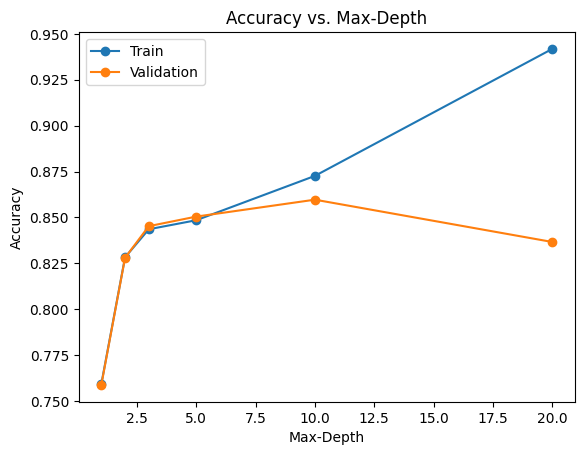

   depth  train_acc  val_acc  nodes
0      1     0.7593   0.7588      3
1      2     0.8283   0.8280      7
2      3     0.8436   0.8452     15
3      5     0.8485   0.8505     55
4     10     0.8726   0.8597    555
5     20     0.9418   0.8366   4101


In [24]:
"""MAX-DEPTH"""
import matplotlib.pyplot as plt

depths = [1, 2, 3, 5, 10, 20]

train_accs = []
val_accs = []
nodes = []

for d in depths:
    clf = DecisionTreeClassifier(max_depth=d, random_state=42)
    tr_acc, val_acc, n = get_results(clf, X_tr, y_tr, X_val, y_val)

    train_accs.append(tr_acc)
    val_accs.append(val_acc)
    nodes.append(n)

plt.plot(depths, train_accs, marker="o", label="Train")
plt.plot(depths, val_accs, marker="o", label="Validation")

plt.xlabel("Max-Depth")
plt.ylabel("Accuracy")
plt.title("Accuracy vs. Max-Depth")
plt.legend()
plt.show()

df_depth = pd.DataFrame({
    "depth": depths,
    "train_acc": train_accs,
    "val_acc": val_accs,
    "nodes": nodes})
print(df_depth.round(4))

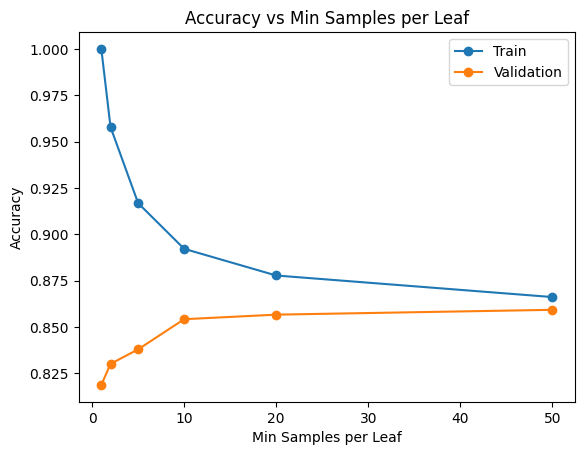

   Leaf Size  Train Acc  Val Acc  Nodes
0          1     1.0000   0.8187   7463
1          2     0.9578   0.8300   6157
2          5     0.9168   0.8379   3633
3         10     0.8921   0.8541   2203
4         20     0.8777   0.8566   1259
5         50     0.8661   0.8592    589


In [25]:
leaf_sizes = [1, 2, 5, 10, 20, 50]

train_accs = []
val_accs = []
nodes = []

for leaf in leaf_sizes:
    clf = DecisionTreeClassifier(min_samples_leaf=leaf, random_state=42)
    tr_acc, val_acc, n = get_results(clf, X_tr, y_tr, X_val, y_val)

    train_accs.append(tr_acc)
    val_accs.append(val_acc)
    nodes.append(n)

plt.plot(leaf_sizes, train_accs, marker='o', label="Train")
plt.plot(leaf_sizes, val_accs, marker='o', label="Validation")

plt.xlabel("Min Samples per Leaf")
plt.ylabel("Accuracy")
plt.title("Accuracy vs Min Samples per Leaf")
plt.legend()
plt.show()

df_depth = pd.DataFrame({
    "Leaf Size": leaf_sizes,
    "Train Acc": train_accs,
    "Val Acc": val_accs,
    "Nodes": nodes
})

print(df_depth.round(4))

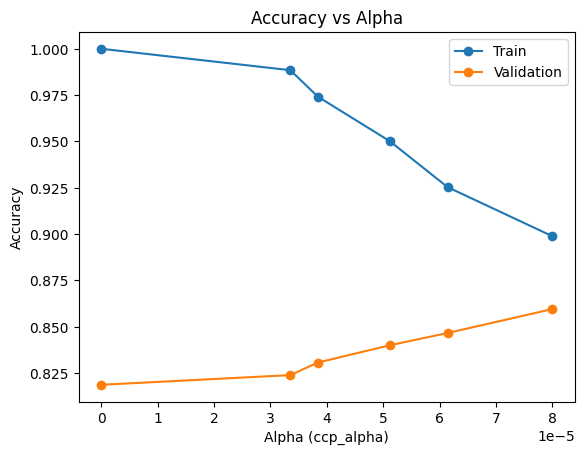

      Alpha  Train Acc   Val Acc  Nodes
0  0.000000   1.000000  0.818670   7463
1  0.000034   0.988444  0.823891   6075
2  0.000038   0.974201  0.830646   4709
3  0.000051   0.950092  0.840012   3149
4  0.000061   0.925330  0.846614   1949
5  0.000080   0.898879  0.859512    845


In [27]:
path = DecisionTreeClassifier(random_state=42).cost_complexity_pruning_path(X_tr, y_tr)
alphas = path.ccp_alphas
alphas = alphas[::max(1, len(alphas) // 6)]

train_accs = []
val_accs = []
nodes = []

for a in alphas:
    clf = DecisionTreeClassifier(ccp_alpha=a, random_state=42)
    tr_acc, val_acc, n = get_results(clf, X_tr, y_tr, X_val, y_val)

    train_accs.append(tr_acc)
    val_accs.append(val_acc)
    nodes.append(n)

plt.plot(alphas, train_accs, marker='o', label="Train")
plt.plot(alphas, val_accs, marker='o', label="Validation")

plt.xlabel("Alpha (ccp_alpha)")
plt.ylabel("Accuracy")
plt.title("Accuracy vs Alpha")
plt.legend()
plt.show()

df_depth = pd.DataFrame({
    "Alpha": alphas,
    "Train Acc": train_accs,
    "Val Acc": val_accs,
    "Nodes": nodes
})

print(df_depth.round(10))

In [32]:
"""QUESTION 2A"""
from sklearn.ensemble import RandomForestClassifier

trees = [10, 50, 100, 500]
results = []

for t in trees:
    rf = RandomForestClassifier(n_estimators=t, random_state=42, n_jobs=-1)
    rf.fit(X_train, y_train)

    y_train_pred = rf.predict(X_train)
    y_test_pred = rf.predict(X_test)

    y_train_prob = rf.predict_proba(X_train)[:, 1]
    y_test_prob = rf.predict_proba(X_test)[:, 1]

    train_metrics = evaluate(y_train, y_train_pred, y_train_prob)
    test_metrics = evaluate(y_test, y_test_pred, y_test_prob)

    df = pd.DataFrame({
        "Train": {k: float(v) for k, v in train_metrics.items()},
        "Test": {k: float(v) for k, v in test_metrics.items()}
    }).round(4)

    print(f"\n=== T = {t} ===")
    print(df)


=== T = 10 ===
            Train    Test
Accuracy   0.9868  0.8479
Error      0.0132  0.1521
Precision  0.9941  0.7186
Recall     0.9509  0.5855
F1         0.9720  0.6453
AUC        0.9994  0.8746

=== T = 50 ===
            Train    Test
Accuracy   0.9998  0.8511
Error      0.0002  0.1489
Precision  0.9999  0.7183
Recall     0.9991  0.6079
F1         0.9995  0.6585
AUC        1.0000  0.8972

=== T = 100 ===
            Train    Test
Accuracy   1.0000  0.8518
Error      0.0000  0.1482
Precision  0.9999  0.7204
Recall     1.0000  0.6089
F1         0.9999  0.6600
AUC        1.0000  0.9005

=== T = 500 ===
            Train    Test
Accuracy   1.0000  0.8528
Error      0.0000  0.1472
Precision  1.0000  0.7197
Recall     0.9999  0.6175
F1         0.9999  0.6647
AUC        1.0000  0.9024


                                            Feature  Importance
103                                     num__fnlwgt    0.163113
102                                        num__age    0.150303
105                               num__capital-gain    0.093964
107                             num__hours-per-week    0.083783
27           cat__marital-status_Married-civ-spouse    0.065020
..                                              ...         ...
88   cat__native-country_Outlying-US(Guam-USVI-etc)    0.000024
34                     cat__occupation_Armed-Forces    0.000013
76                     cat__native-country_Honduras    0.000005
3                       cat__workclass_Never-worked    0.000003
75           cat__native-country_Holand-Netherlands    0.000001

[108 rows x 2 columns]


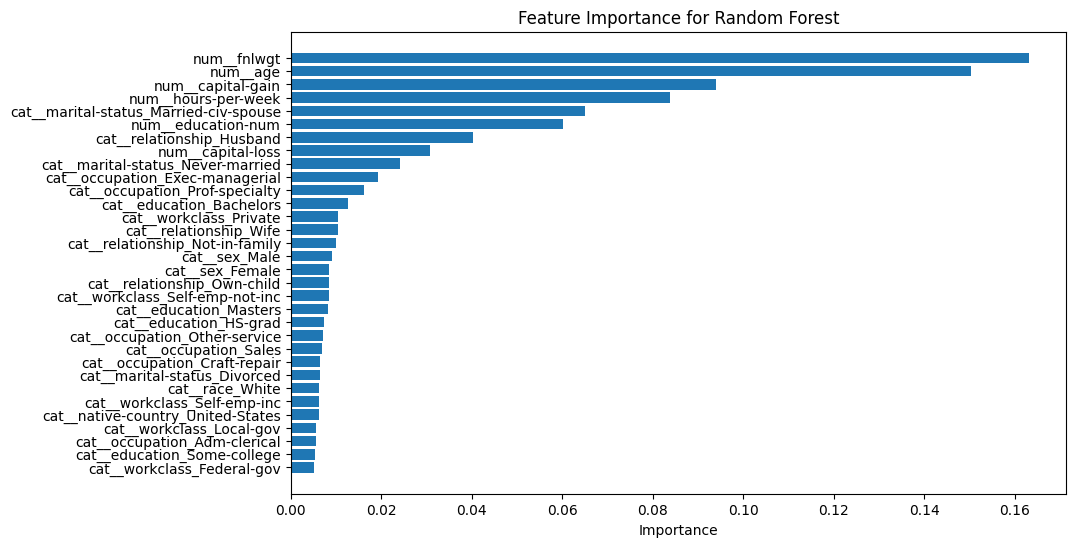

In [42]:
"""QUESTION 2C"""
feature_names = preprocessor.get_feature_names_out()

rf = RandomForestClassifier(n_estimators=500, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

importances = rf.feature_importances_
feat_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
})
feat_df.sort_values(by="Importance", ascending=False, inplace=True)
print(feat_df)
# len(feat_df) = 108

top_k = 32
top_feat = feat_df.head(top_k)

plt.figure(figsize=(10,6))
plt.barh(top_feat["Feature"], top_feat["Importance"])
plt.gca().invert_yaxis()

plt.xlabel("Importance")
plt.title("Feature Importance for Random Forest")
plt.show()

In [45]:
"""QUESTION 3A"""
from sklearn.ensemble import AdaBoostClassifier, GradientBoostingClassifier

trees = [10, 50, 100, 500]
results = []

for t in trees:
    base_tree = DecisionTreeClassifier(max_depth=3, random_state=42)
    ada = AdaBoostClassifier(estimator=base_tree, random_state=42, n_estimators=t, learning_rate=0.1)
    gb = GradientBoostingClassifier(n_estimators=t, learning_rate=0.1, max_depth=3, random_state=42)

    for model_name, model in [("AdaBoost", ada), ("GradientBoost", gb)]:

        model.fit(X_train, y_train)

        y_train_pred = model.predict(X_train)
        y_test_pred = model.predict(X_test)

        y_train_prob = model.predict_proba(X_train)[:, 1]
        y_test_prob = model.predict_proba(X_test)[:, 1]

        train_metrics = evaluate(y_train, y_train_pred, y_train_prob)
        test_metrics = evaluate(y_test, y_test_pred, y_test_prob)

        results.append({
            "Model": model_name,
            "Trees": t,

            "Train_Accuracy": train_metrics["Accuracy"],
            "Train_Precision": train_metrics["Precision"],
            "Train_Recall": train_metrics["Recall"],
            "Train_F1": train_metrics["F1"],
            "Train_AUC": float(train_metrics["AUC"]),

            "Test_Accuracy": test_metrics["Accuracy"],
            "Test_Precision": test_metrics["Precision"],
            "Test_Recall": test_metrics["Recall"],
            "Test_F1": test_metrics["F1"],
            "Test_AUC": float(test_metrics["AUC"]),
        })

rows = []
for _, r in df_boost.iterrows():
    for metric in ["Accuracy", "Precision", "Recall", "F1", "AUC"]:
        rows.append({
            "Model": r["Model"],
            "Trees": r["Trees"],
            "Metric": metric,
            "Train": r[f"Train_{metric}"],
            "Test": r[f"Test_{metric}"]
        })

df_long = pd.DataFrame(rows).round(4)

print(df_long)

            Model  Trees     Metric   Train    Test
0        AdaBoost     10   Accuracy  0.8486  0.8499
1        AdaBoost     10  Precision  0.7594  0.7579
2        AdaBoost     10     Recall  0.5436  0.5356
3        AdaBoost     10         F1  0.6336  0.6277
4        AdaBoost     10        AUC  0.8695  0.8699
5   GradientBoost     10   Accuracy  0.8448  0.8474
6   GradientBoost     10  Precision  0.8196  0.8217
7   GradientBoost     10     Recall  0.4561  0.4519
8   GradientBoost     10         F1  0.5860  0.5831
9   GradientBoost     10        AUC  0.8898  0.8905
10       AdaBoost     50   Accuracy  0.8535  0.8544
11       AdaBoost     50  Precision  0.7943  0.7901
12       AdaBoost     50     Recall  0.5285  0.5226
13       AdaBoost     50         F1  0.6347  0.6291
14       AdaBoost     50        AUC  0.9064  0.9053
15  GradientBoost     50   Accuracy  0.8613  0.8643
16  GradientBoost     50  Precision  0.7968  0.7969
17  GradientBoost     50     Recall  0.5694  0.5712
18  Gradient

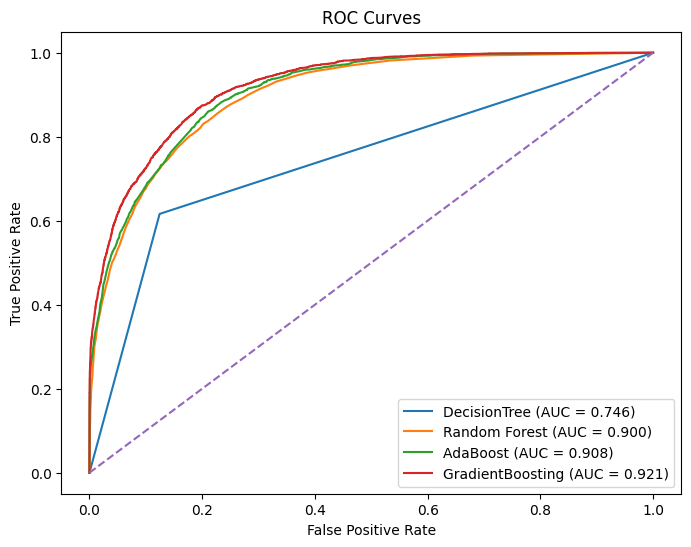

In [46]:
"""QUESTION 3C"""
from sklearn.metrics import roc_curve, auc

dt = DecisionTreeClassifier(criterion="entropy", random_state=42)
dt.fit(X_train, y_train)

rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

base_tree = DecisionTreeClassifier(max_depth=3, random_state=42)

ada = AdaBoostClassifier(estimator=base_tree, random_state=42, n_estimators=100, learning_rate=0.1)
ada.fit(X_train, y_train)

gb = GradientBoostingClassifier(n_estimators=100, random_state=42, learning_rate=0.1, max_depth=3)
gb.fit(X_train, y_train)

models = {
    "DecisionTree": dt,
    "Random Forest": rf,
    "AdaBoost": ada,
    "GradientBoosting": gb
}

plt.figure(figsize=(8,6))

for name, model in models.items():
    y_prob = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc:.3f})")

plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves")
plt.legend()
plt.show()

In [50]:
"""QUESTION 4"""
columns = [
    "class", "cap-shape", "cap-surface", "cap-color", "bruises", "odor",
    "gill-attachment", "gill-spacing", "gill-size", "gill-color",
    "stalk-shape", "stalk-root", "stalk-surface-above-ring",
    "stalk-surface-below-ring", "stalk-color-above-ring",
    "stalk-color-below-ring", "veil-type", "veil-color",
    "ring-number", "ring-type", "spore-print-color",
    "population", "habitat"
]
df = pd.read_csv("agaricus-lepiota.data", names=columns)
df = df.replace("?", np.nan)
df = df.dropna()

df["class"] = df["class"].map({ "e": 0, "p": 1 })
X = df.drop("class", axis=1)
y = df["class"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)
feature_values = {
    col: X_train[col].unique()
    for col in X_train.columns
}

print(df["class"].value_counts())

class
0    3488
1    2156
Name: count, dtype: int64


In [55]:
"""QUESTION 4A"""
priors = {
    0: (y_train == 0).mean(),
    1: (y_train == 1).mean()
}
print("P(Edible):", round(priors[0], 4))
print("P(Poisonous):", round(priors[1], 4))

cond_probs = { 0: {}, 1: {} }

for feature in X_train.columns:
    cond_probs[0][feature] = {}
    cond_probs[1][feature] = {}

    values = X_train[feature].unique()
    K = len(values)

    for c in [0, 1]:
        X_c = X_train[y_train == c]
        total_c = len(X_c)

        for val in values:
            count = (X_c[feature] == val).sum()
            prob = (count + 1) / (total_c + K)
            cond_probs[c][feature][val] = prob

P(Edible): 0.618
P(Poisonous): 0.382


In [56]:
feature = "bruises"
rows = []
for val in X_train[feature].unique():
    rows.append({
        "Value": val,
        "P(val | Edible)": cond_probs[0][feature][val],
        "P(val | Poisonous)": cond_probs[1][feature][val]
    })

pd.DataFrame(rows).round(4)

,Value,P(val | Edible),P(val | Poisonous)
0,f,0.2659,0.7103
1,t,0.7341,0.2897


In [62]:
"""QUESTION 4B"""
def predict_naive_bayes(X, priors, cond_probs):
    predictions = []
    prob_estimates = []

    for _, row in X.iterrows():
        log_probs = {}

        for c in [0, 1]:
            log_prob = np.log(priors[c])

            for feature in X.columns:
                val = row[feature]
                prob = cond_probs[c][feature].get(val, 1e-9)
                log_prob += np.log(prob)
            log_probs[c] = log_prob

        max_log = max(log_probs.values())
        exp_probs = { c: np.exp(log_probs[c] - max_log) for c in [0, 1] }
        total = sum(exp_probs.values())

        probs = { c: exp_probs[c] / total for c in [0, 1] }
        pred = max(probs, key=probs.get)

        predictions.append(pred)
        prob_estimates.append(probs)

    return predictions, prob_estimates

y_pred, y_prob = predict_naive_bayes(X_test, priors, cond_probs)

sample_df = pd.DataFrame({
    "P(Edible)": [p[0] for p in y_prob[:5]],
    "P(Poisonous)": [p[1] for p in y_prob[:5]],
    "Predicted": y_pred[:5],
    "Actual": y_test.iloc[:5].values
}).round(4)
sample_df

,P(Edible),P(Poisonous),Predicted,Actual
0,1.0,0.0,0,0
1,0.0,1.0,1,1
2,1.0,0.0,0,0
3,0.0,1.0,1,1
4,1.0,0.0,0,0


In [64]:
"""QUESTION 4C"""
nb_metrics = {
    "Accuracy": accuracy_score(y_test, y_pred),
    "Precision": precision_score(y_test, y_pred),
    "Recall": recall_score(y_test, y_pred),
    "F1": f1_score(y_test, y_pred)
}

df_nb = pd.DataFrame(nb_metrics, index=["Naive Bayes"]).round(4)
print(df_nb)

             Accuracy  Precision  Recall      F1
Naive Bayes    0.9702      0.996  0.9258  0.9596


In [69]:
"""QUESTION 4D"""
from sklearn.preprocessing import OrdinalEncoder
from sklearn.naive_bayes import CategoricalNB

categorical_cols = X_train.select_dtypes(include=["object"]).columns
numerical_cols = X_train.select_dtypes(exclude=["object"]).columns

encoder = OrdinalEncoder()

X_train_nb = X_train.copy()
X_test_nb = X_test.copy()

X_train_nb[categorical_cols] = encoder.fit_transform(X_train[categorical_cols])
X_test_nb[categorical_cols] = encoder.transform(X_test[categorical_cols])

# Everything is Numeric..
X_train_nb = X_train_nb.astype(int)
X_test_nb = X_test_nb.astype(int)

nb_model = CategoricalNB()
nb_model.fit(X_train_nb, y_train)

y_pred_nb = nb_model.predict(X_test_nb)
y_prob_nb = nb_model.predict_proba(X_test_nb)[:, 1]

nb_metrics_sklearn = {
    "Accuracy": accuracy_score(y_test, y_pred_nb),
    "Precision": precision_score(y_test, y_pred_nb),
    "Recall": recall_score(y_test, y_pred_nb),
    "F1": f1_score(y_test, y_pred_nb)
}
print(nb_metrics_sklearn)
df_nb_library = pd.DataFrame({
    "Metrics": nb_metrics_sklearn,
})
df_nb_library

{'Accuracy': 0.9702338766832034, 'Precision': 0.9960079840319361, 'Recall': 0.9257884972170687, 'F1': 0.9596153846153846}


,Metrics
Accuracy,0.970234
Precision,0.996008
Recall,0.925788
F1,0.959615
